# Explore here

## Paso 1: 
***Carga del conjunto de datos***

In [1]:
# Your code here

%pip install -r ../requirements.txt

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

df = pd.read_csv('https://breathecode.herokuapp.com/asset/internal-link?id=932&path=url_spam.csv')

df.head()

,url,is_spam
0,https://briefingday.us8.list-manage.com/unsubs...,True
1,https://www.hvper.com/,True
2,https://briefingday.com/m/v4n3i4f3,True
3,https://briefingday.com/n/20200618/m#commentform,False
4,https://briefingday.com/fan,True


## Paso 2:
***Preprocesa los enlaces***

Utiliza lo visto en este módulo para transformar los datos para compatibilizarlos con el modelo que queremos entrenar. Segmenta las URLs en partes según sus signos de puntuación, elimina las stopwords, lematiza, etcétera.

Asegúrate de dividir convenientemente el conjunto de datos en ***train*** y ***test*** como hemos visto en lecciones anteriores.



In [3]:
df['is_spam'] = df['is_spam'].apply(lambda x: 1 if x == True else 0).astype(int)

df.head()

,url,is_spam
0,https://briefingday.us8.list-manage.com/unsubs...,1
1,https://www.hvper.com/,1
2,https://briefingday.com/m/v4n3i4f3,1
3,https://briefingday.com/n/20200618/m#commentform,0
4,https://briefingday.com/fan,1


In [4]:
print(f"Spam {len(df.loc[df['is_spam'] == 1])}")
print(f"No Spam {len(df.loc[df['is_spam'] == 0])}")

Spam 696
No Spam 2303


In [5]:
df.drop_duplicates(inplace=True)

In [6]:
print(f"Spam {len(df.loc[df['is_spam'] == 1])}")
print(f"No Spam {len(df.loc[df['is_spam'] == 0])}")

Spam 244
No Spam 2125


In [7]:
df.reset_index(drop=True, inplace=True)

df

,url,is_spam
0,https://briefingday.us8.list-manage.com/unsubs...,1
1,https://www.hvper.com/,1
2,https://briefingday.com/m/v4n3i4f3,1
3,https://briefingday.com/n/20200618/m#commentform,0
4,https://briefingday.com/fan,1
...,...,...
2364,https://www.theverge.com/2020/6/29/21306889/di...,0
2365,https://www.smartcitiesworld.net/news/news/dee...,0
2366,https://techcrunch.com/2019/07/04/an-optimisti...,0
2367,https://www.technologyreview.com/2019/12/20/13...,0


In [8]:
%pip install regex

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [9]:
import regex as re

def preprocess_text(text):
    # Remueve caracteres que no sean letras o /
    text = re.sub(r'[^\p{L}/\s.]', '', text)
    
    #Reemplazar // por /
    text = text.replace('//','/')
    
    #Separa por / y por . a la vez
    return re.split(r'[/.]', text)

texto_prueba = 'https://briefingday.com//fan'
print(preprocess_text(texto_prueba))
    

['https', 'briefingday', 'com', 'fan']


In [10]:
df['url'] = df['url'].apply(preprocess_text)
df.head()

,url,is_spam
0,"[https, briefingday, us, listmanage, com, unsu...",1
1,"[https, www, hvper, com, ]",1
2,"[https, briefingday, com, m, vnif]",1
3,"[https, briefingday, com, n, mcommentform]",0
4,"[https, briefingday, com, fan]",1


In [11]:
%pip install WordCloud

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


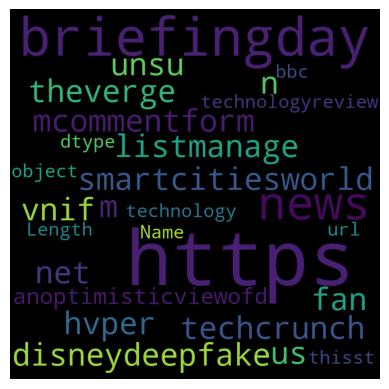

In [12]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud 

nube = WordCloud(width=800, height=800, background_color='black', max_words=1000, min_font_size=20, random_state=42)\
    .generate(str(df['url']))

plt.imshow(nube)
plt.axis('off')
plt.show()

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

lista_tokenizable = df['url']
lista_tokenizable = [" ".join(tokens) for tokens in lista_tokenizable]

vectorizador = TfidfVectorizer(max_features=10000, max_df= 0.8, min_df=5)
X = vectorizador.fit_transform(lista_tokenizable).toarray()
y = df['is_spam']

X[:1]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.51974885, 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.  

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train

array([[0.        , 0.        , 0.        , ..., 0.        , 0.21119963,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.13753315,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.19364653,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 1.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

## Paso 3:
***Construye un SVM***

Comienza a resolver el problema implementando un SVM con los parámetros por defecto. Entrénalo y analiza sus resultados.

